In [1]:
# ── Cell 2: Imports ──
import os
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# ── Cell 3: Mount Drive and load data ──
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
X_train = np.load("/content/drive/MyDrive/X_train.npy")
y_train = np.load("/content/drive/MyDrive/y_train.npy")
X_val   = np.load("/content/drive/MyDrive/X_val.npy")
y_val   = np.load("/content/drive/MyDrive/y_val.npy")

In [5]:
print(f"X_train: {X_train.nbytes / 1e9:.2f} GB")
print(f"X_val:   {X_val.nbytes / 1e9:.2f} GB")
print(f"Total:   {(X_train.nbytes + X_val.nbytes) / 1e9:.2f} GB")

X_train: 13.36 GB
X_val:   1.86 GB
Total:   15.22 GB


In [6]:
print(f"Train: {len(X_train)} — Tumor: {int(y_train.sum())}, Normal: {int((y_train==0).sum())}")
print(f"Val:   {len(X_val)} — Tumor: {int(y_val.sum())}, Normal: {int((y_val==0).sum())}")
print(f"Patch shape: {X_train[0].shape}")

Train: 67961 — Tumor: 34374, Normal: 33587
Val:   9442 — Tumor: 4632, Normal: 4810
Patch shape: (256, 256, 3)


In [7]:
print(f"X_val: {len(X_val)}")
print(f"y_val: {len(y_val)}")

X_val: 9442
y_val: 9442


In [8]:
# ── X_train ──
means_train = X_train.reshape(len(X_train), -1).mean(axis=1)

print(f"── X_train ──")
print(f"Total patches:              {len(means_train)}")
print(f"Black patches (mean < 10):  {(means_train < 10).sum()}")
print(f"Dark patches  (mean < 20):  {(means_train < 20).sum()}")
print(f"White patches (mean > 220): {(means_train > 220).sum()}")
print(f"Bright patches(mean > 200): {(means_train > 200).sum()}")
print(f"Min patch mean:             {means_train.min():.1f}")
print(f"Max patch mean:             {means_train.max():.1f}")
print(f"Avg patch mean:             {means_train.mean():.1f}")

── X_train ──
Total patches:              67961
Black patches (mean < 10):  0
Dark patches  (mean < 20):  0
White patches (mean > 220): 0
Bright patches(mean > 200): 0
Min patch mean:             30.5
Max patch mean:             200.0
Avg patch mean:             153.5


In [9]:
means_val = X_val.reshape(len(X_val), -1).mean(axis=1)

print(f"── X_val ──")
print(f"Total patches:              {len(means_val)}")
print(f"Black patches (mean < 10):  {(means_val < 10).sum()}")
print(f"Dark patches  (mean < 20):  {(means_val < 20).sum()}")
print(f"White patches (mean > 220): {(means_val > 220).sum()}")
print(f"Bright patches(mean > 200): {(means_val > 200).sum()}")
print(f"Min patch mean:             {means_val.min():.1f}")
print(f"Max patch mean:             {means_val.max():.1f}")
print(f"Avg patch mean:             {means_val.mean():.1f}")

── X_val ──
Total patches:              9442
Black patches (mean < 10):  0
Dark patches  (mean < 20):  0
White patches (mean > 220): 0
Bright patches(mean > 200): 0
Min patch mean:             30.1
Max patch mean:             200.0
Avg patch mean:             153.0


In [10]:
# ── Cell 4: Dataset and DataLoaders ──
class CAMELYONDataset(Dataset):
    def __init__(self, patches, labels, transform=None):
        self.X         = patches  # keep as numpy, uint8
        self.y         = torch.tensor(labels)
        self.transform = transform
        self.mean      = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std       = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = torch.tensor(self.X[idx], dtype=torch.float32) / 255.0
        image = image.permute(2, 0, 1)
        image = (image - self.mean) / self.std
        if self.transform:
            image = self.transform(image)
        return image, self.y[idx]

In [11]:
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90)
])

In [12]:
train_dataset = CAMELYONDataset(X_train, y_train, transform = train_transforms)
val_dataset = CAMELYONDataset(X_val, y_val, transform = None)

In [13]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset,   batch_size=32, shuffle=False)

In [14]:
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

Train batches: 2124
Val batches:   296


In [15]:
# ── Cell 5: Model ──
class EfficientNetClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.base = models.efficientnet_b0(weights='IMAGENET1K_V1')
        for param in self.base.parameters():
            param.requires_grad = False
        self.base.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(1280, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.base(x)

In [16]:
model = EfficientNetClassifier().to(device)
print("Model ready!")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 101MB/s] 


Model ready!


In [17]:
# Unfreeze layers 6, 7, 8
for layer in list(model.base.features.children())[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

In [18]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")

Trainable parameters: 1,293,489


In [19]:
# ── Cell 6: Training loop ──
optimizer = optim.Adam(model.parameters(), lr=0.00001, weight_decay=1e-5)
loss_fn   = nn.BCEWithLogitsLoss()
epochs    = 30

best_val_loss    = float("inf")
patience         = 5
patience_counter = 0

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}  # ← new

for epoch in range(epochs):

    model.train()
    train_loss    = 0
    train_correct = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        train_correct += (preds == labels).sum().item()

    model.eval()
    val_loss = 0
    val_correct = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            loss = loss_fn(outputs, labels)

            val_loss += loss.item()
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            val_correct += (preds == labels).sum().item()

    train_acc = train_correct / len(train_dataset)
    val_acc = val_correct   / len(val_dataset)
    avg_train_loss = train_loss    / len(train_loader)
    avg_val_loss = val_loss      / len(val_loader)

    history["train_loss"].append(avg_train_loss)  # ← new
    history["train_acc"].append(train_acc)         # ← new
    history["val_loss"].append(avg_val_loss)        # ← new
    history["val_acc"].append(val_acc)              # ← new

    print(f"Epoch {epoch+1}/{epochs} "
          f"| train loss: {avg_train_loss:.4f} "
          f"| train acc: {train_acc:.4f} "
          f"| val loss: {avg_val_loss:.4f} "
          f"| val acc: {val_acc:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "/content/drive/MyDrive/efficientnet_cam16train_cam17val_256_frozen_transformed_finetuned_2layer_v3_weight_decay1e5.pth")
        print(f"  --> saved best model")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping.")
            break

Epoch 1/30 | train loss: 0.2913 | train acc: 0.8917 | val loss: 0.2232 | val acc: 0.9168
  --> saved best model
Epoch 2/30 | train loss: 0.1633 | train acc: 0.9377 | val loss: 0.2459 | val acc: 0.9013
Epoch 3/30 | train loss: 0.1428 | train acc: 0.9460 | val loss: 0.2137 | val acc: 0.9179
  --> saved best model
Epoch 4/30 | train loss: 0.1300 | train acc: 0.9512 | val loss: 0.2243 | val acc: 0.9124
Epoch 5/30 | train loss: 0.1212 | train acc: 0.9542 | val loss: 0.2380 | val acc: 0.9092
Epoch 6/30 | train loss: 0.1147 | train acc: 0.9573 | val loss: 0.2449 | val acc: 0.9046
Epoch 7/30 | train loss: 0.1094 | train acc: 0.9595 | val loss: 0.2438 | val acc: 0.9062
Epoch 8/30 | train loss: 0.1068 | train acc: 0.9603 | val loss: 0.2344 | val acc: 0.9115
Early stopping.


In [20]:
with open("/content/drive/MyDrive/training_history_2layer_decay1e5.json", "w") as f:
    json.dump(history, f)
print("History saved!")

History saved!


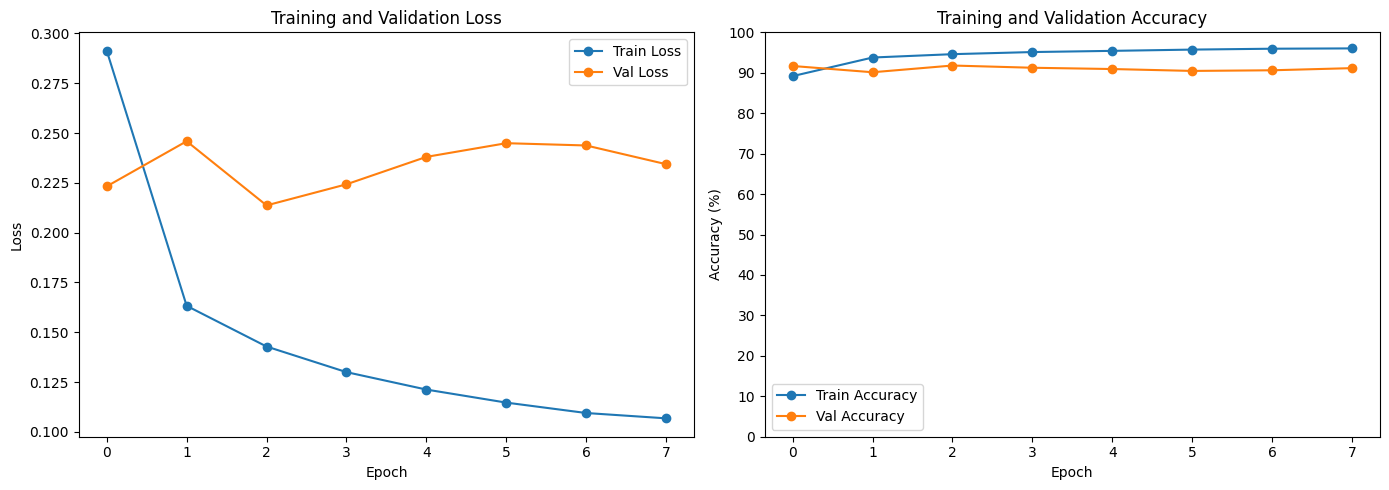

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss", marker='o')
axes[0].plot(history["val_loss"], label="Val Loss", marker='o')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training and Validation Loss")
axes[0].legend()

train_acc_pct = [a * 100 for a in history["train_acc"]]
val_acc_pct   = [a * 100 for a in history["val_acc"]]

axes[1].plot(train_acc_pct, label="Train Accuracy", marker='o')
axes[1].plot(val_acc_pct, label="Val Accuracy", marker='o')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Training and Validation Accuracy")
axes[1].set_ylim(0, 100)
axes[1].set_yticks(np.arange(0, 101, 10))
axes[1].legend()

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/training_curves.png", dpi=150)
plt.show()

In [21]:
# ── Cell 7: Restore best model ──
model.load_state_dict(torch.load("/content/drive/MyDrive/efficientnet_cam16train_cam17val_256_frozen_transformed_finetuned_2layer_v3_weight_decay1e5.pth"))
print("Best model restored.")

Best model restored.


In [22]:
model.eval()
all_probs  = []
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        outputs = model(images)
        probs   = torch.sigmoid(outputs)
        preds   = (probs >= 0.5).float()

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs  = np.array(all_probs).flatten()
all_preds  = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

print(f"Total val samples: {len(all_labels)}")
print(f"Tumor:  {int(all_labels.sum())}")
print(f"Normal: {int((all_labels==0).sum())}")

Total val samples: 9442
Tumor:  4632
Normal: 4810


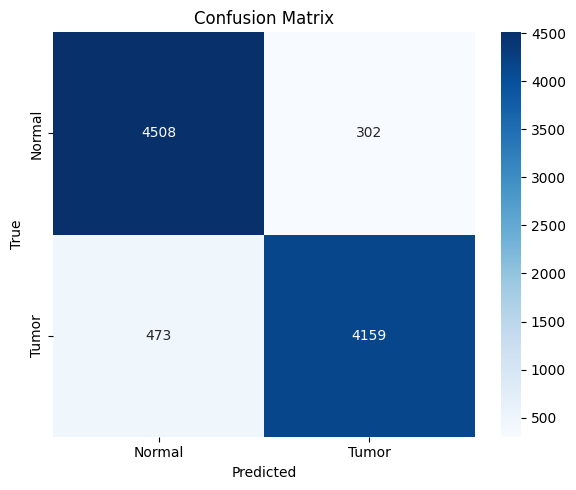

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Tumor'],
            yticklabels=['Normal', 'Tumor'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [24]:
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
precision   = TP / (TP + FP)
accuracy    = (TP + TN) / (TP + TN + FP + FN)

print(f"True Positives  (TP): {TP}")
print(f"True Negatives  (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"\nSensitivity (Recall): {sensitivity:.4f} ({sensitivity*100:.1f}%)")
print(f"Specificity:           {specificity:.4f} ({specificity*100:.1f}%)")
print(f"Precision:             {precision:.4f}   ({precision*100:.1f}%)")
print(f"Accuracy:              {accuracy:.4f}    ({accuracy*100:.1f}%)")

True Positives  (TP): 4159
True Negatives  (TN): 4508
False Positives (FP): 302
False Negatives (FN): 473

Sensitivity (Recall): 0.8979 (89.8%)
Specificity:           0.9372 (93.7%)
Precision:             0.9323   (93.2%)
Accuracy:              0.9179    (91.8%)


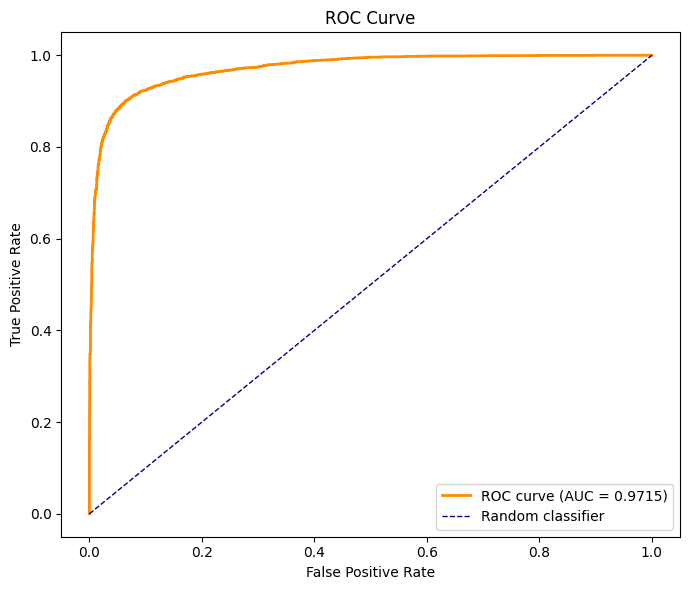

AUC: 0.9715


In [25]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()

print(f"AUC: {roc_auc:.4f}")

In [26]:
# Config — extracted directly from the training code above
config = {
    "architecture":    "EfficientNetB0",
    "unfrozen_layers": 2,
    "optimizer":        "Adam",
    "lr":                0.00001,
    "weight_decay":      1e-5,
    "loss_function":     "BCEWithLogitsLoss",
    "max_epochs":        30,
    "patience":          5,
    "batch_size":        32,
    "train_patches":     len(train_dataset),
    "val_patches":       len(val_dataset),
    "model_file":        "efficientnet_cam16train_cam17val_256_frozen_transformed_finetuned_2layer_v3_weight_decay1e5.pth"
}

# Metrics — extracted from actual model evaluation (run after your confusion matrix + ROC cells)
metrics = {
    "TP": int(TP), "TN": int(TN), "FP": int(FP), "FN": int(FN),
    "sensitivity": float(sensitivity),
    "specificity": float(specificity),
    "precision":   float(precision),
    "accuracy":    float(accuracy),
    "auc":         float(roc_auc)
}

result = {"config": config, "metrics": metrics}

In [27]:
with open("/content/drive/MyDrive/results_2layer_decay1e5.json", "w") as f:
    json.dump(result, f, indent=2)

In [28]:
print(json.dumps(result, indent=2))

{
  "config": {
    "architecture": "EfficientNetB0",
    "unfrozen_layers": 2,
    "optimizer": "Adam",
    "lr": 1e-05,
    "weight_decay": 1e-05,
    "loss_function": "BCEWithLogitsLoss",
    "max_epochs": 30,
    "patience": 5,
    "batch_size": 32,
    "train_patches": 67961,
    "val_patches": 9442,
    "model_file": "efficientnet_cam16train_cam17val_256_frozen_transformed_finetuned_2layer_v3_weight_decay1e5.pth"
  },
  "metrics": {
    "TP": 4159,
    "TN": 4508,
    "FP": 302,
    "FN": 473,
    "sensitivity": 0.8978842832469776,
    "specificity": 0.9372141372141373,
    "precision": 0.9323021744003587,
    "accuracy": 0.9179199322177505,
    "auc": 0.9714514684074269
  }
}
